# Алгоритм kNN (k Nearest Neighbors) - k ближайших соседей

Алгоритм kNN относится к метрическим алгоритмам и является одним из самых простых алгоритмов. Используется как для классификации, так и в задачах регрессии.

Для классификации каждого объекта *тестовой выборки* необходимо последовательно выполнить следующие операции:

* вычислить расстояние до каждого из объектов *обучающей выборки*;
* отобрать $k$ объектов обучающей выборки, расстояние до которых *минимально*;
* присвоить класс объекта — класс, наиболее часто встречающийся среди $k$ ближайших соседей.

Алгоритм можно адаптировать под регрессию: в этом случае находится не метка класса, а среднее значение ответа среди $k$ соседей.

<div>
<img src="https://drive.google.com/uc?export=view&id=1AbF4G-hOURboIehuBDG4_EjYoAjT9G2D" width="400"/>
</div>

## Меры и метрики расстояния между объектами

_Евклидова метрика_ ($L_2$ норма)

$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_{i}-y_{i})^{2}}$$

_Манхэттенская метрика_ ($L_1$ норма)

$$d(x, y) = \sum_{i=1}^{n}|x_{i}-y_{i}|$$

Обобщение этих двух метрик - _метрика Минковского_:

$$d(x, y) = \left ( \sum_{i=1}^{n}|x_{i}-y_{i}|^{p} \right )^{\frac{1}{p}}.$$

При этом при $p = 1$ получаем манхэттенскую ($L_{1}$) метрику, при $p = 2$ - евклидову ($L_{2}$) метрику.

Кроме этого, в метрических алгоритмах часто используются так называемые **меры близости**. В отличие от метрик, которые тем меньше, чем объекты более похожи, меры близости увеличиваются при увеличении похожести (близости) объектов.

Примером такой функции может быть _косинусная мера_:

$$\text{cos }\theta = \frac{\left \langle x, y \right \rangle}{||x||_2\cdot||y||_2} = \frac{\sum_{i=1}^{n}x_{i}y_{i}}{\sqrt{\sum_{i=1}^{n}x_{i}^{2}}\sqrt{\sum_{i=1}^{n}y_{i}^{2}}}.$$

Из этой функции также вытекает _косинусное расстояние_:

$$\rho_{cos}(x, y) = 1 - \text{cos }\theta = 1 - \frac{\sum_{i=1}^{n}x_{i}y_{i}}{\sqrt{\sum_{i=1}^{n}x_{i}^{2}}\sqrt{\sum_{i=1}^{n}y_{i}^{2}}}.$$

Косинусная мера часто используется в анализе текстов.

Формула нахождения косинусной меры похожа на _коэффициент корреляции_, который также может быть использован как мера близости и используется обычно в рекомендательных системах:

$$r = \frac{\sum_{i=1}^{n}((x_{i} - \bar{x})(y_{i} - \bar{y}))}{\sqrt{\sum_{i=1}^{n}(x_{i} - \bar{x})^{2}}\sqrt{\sum_{i=1}^{n}(y_{i} - \bar{y})^{2}}}.$$

## Реализация алгоритма kNN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

In [3]:
# import warnings
# warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.2)
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 50)

Загрузим датасет iris.

<div>
<img src="https://drive.google.com/uc?export=view&id=1WKmR0D_HhF-s5xEPhj9xAqCJ4T8ue8Lz" width="250"/>
</div>

In [4]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
# Для наглядности возьмем только первые два признака (всего в датасете их 4)
X = X[:, :2]

Разделим выборку на обучающую и валидационную.

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

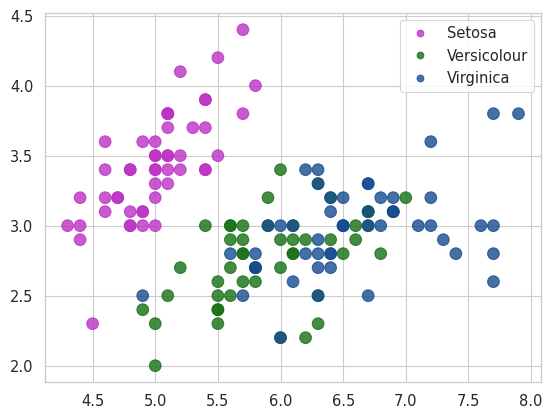

In [6]:
cmap = ListedColormap(['#bd31c4', '#157015','#154c8f'])
scatter = plt.scatter(X[:,0], X[:,1],
                      alpha=0.8, s=70, c=y,
                      cmap=cmap)
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Setosa','Versicolour','Virginica']);

Для расчета расстояния будем использовать евклидову метрику.

In [7]:
a = np.array([0, 0, 0, 0])
b = np.array([1, 1, 1, 1])
dist = np.linalg.norm(a-b) # default is 2-norm
print(dist)

2.0


Реализуем алгоритм поиска k ближайших соседей.

In [8]:
def knn(x_train, y_train, x_test, k):
    predictions = []
    for x in x_test:
        distances = []
        for i in range(len(x_train)):
            # расчет расстояния от классифицируемого объекта до
            # объекта обучающей выборки
            distance = np.linalg.norm(x - x_train[i])
            # записываем в список значение расстояния и ответ на объекте обучающей выборки
            distances.append((distance, y_train[i]))
        # отберем k ближайших соседей
        k_neighbours = sorted(distances)[0:k]
        # создаем словарь со всеми возможными классами
        classes = {label: 0 for label in set(y_train)}
        # cортируем список и среди первых k элементов подсчитаем частоту появления разных классов
        for d in k_neighbours:
            classes[d[1]] += 1 # вес каждого соседа равен 1
        # записываем в список ответов наиболее часто встречающийся класс
        predictions.append(sorted(classes, key=classes.get)[-1])
    return predictions

Проверим работу алгоритма при различных k.

In [9]:
k = 1
pred = knn(X_train, y_train, X_valid, k)
print(f'Точность алгоритма при k = {k}: {accuracy_score(pred, y_valid):.3f}')

Точность алгоритма при k = 1: 0.700


In [10]:
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

def knn_viz(data, labels, k):
    cmap1 = ListedColormap(['#FFAAAA', '#AAFFAA','#8cbfe6'])
    cmap = ListedColormap(['#bd31c4', '#157015','#154c8f'])
    xx, yy = get_grid(data)
    # Получим предсказания для всех точек
    pred = knn(data, labels, np.c_[xx.ravel(), yy.ravel()], k)

    # Построим график
    pred = np.array(pred).reshape(xx.shape)
    #plt.figure(figsize=(7,7))
    plt.pcolormesh(xx, yy, pred, cmap=cmap1)

    # Добавим на график обучающую выборку
    plt.scatter(data[:, 0], data[:, 1], c=labels,
                s=50, cmap=cmap)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f"kNN классификация при k = {k}");

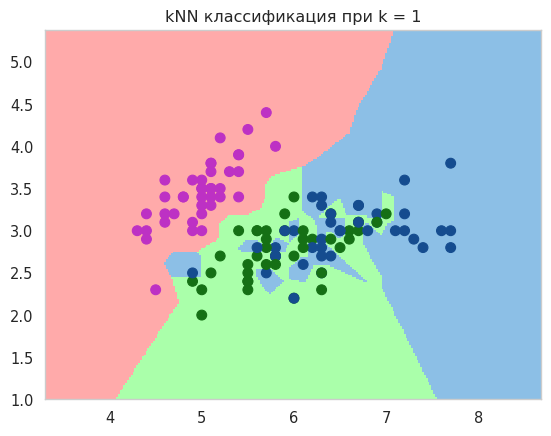

In [11]:
knn_viz(X_train, y_train, k=1)

In [12]:
k = 5
pred = knn(X_train, y_train, X_valid, k)
print(f'Точность алгоритма при k = {k}: {accuracy_score(pred, y_valid):.3f}')

Точность алгоритма при k = 5: 0.800


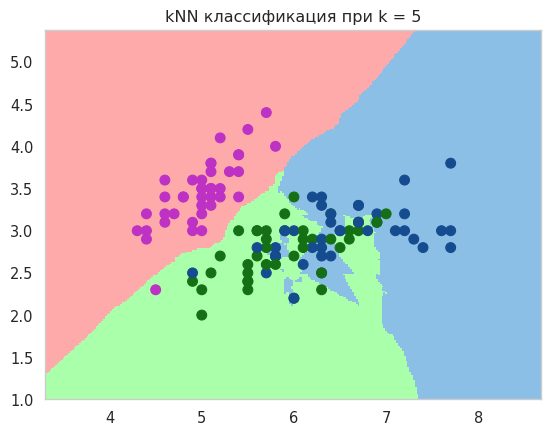

In [13]:
knn_viz(X_train, y_train, k=5)

In [14]:
k = 15
pred = knn(X_train, y_train, X_valid, k)
print(f'Точность алгоритма при k = {k}: {accuracy_score(pred, y_valid):.3f}')

Точность алгоритма при k = 15: 0.833


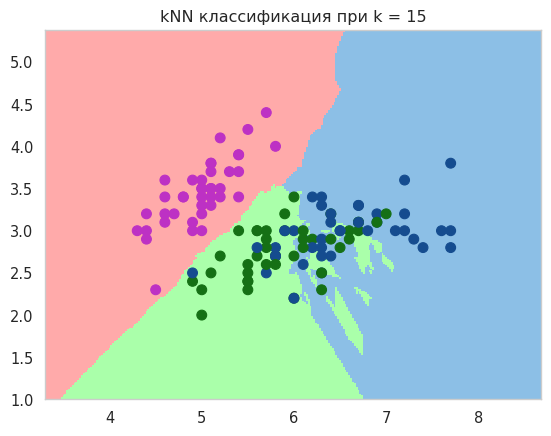

In [15]:
knn_viz(X_train, y_train, k=15)

При увеличении $k$ на графиках наблюдаем, что алгоритм меньше концентрируется на выбросах, однако, точность на тестовой выборке при этом увеличивается.

Рассматриваемый метод, несмотря на положительные стороны в виде легкости интерпретации, простоты и удобства использования, обладает некоторыми минусами, в частности, он плохо работает на датасетах с большим количеством признаков или когда количество признаков сравнимо с количеством объектов ("Проклятие размерности" - см. Дополнительный материал).

## Модель KNeighborsClassifier из библиотеки scikit-learn

In [16]:
from sklearn.neighbors import KNeighborsClassifier

KNeighborsClassifier().get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

### Параметры KNeighborsClassifier

- `n_neighbors`, default=5 - количество соседей
- `weights`: {‘uniform’, ‘distance’}, default=’uniform’ - веса соседей. если `weights`=‘uniform’, то веса одинаковы. Если `weights`=‘distance’, то чем ближе сосед к оцениваемому объекту, тем его вес больше.
- `metric`, default=’minkowski’ - метрика, используемая для расчета расстояния
- `p`, default=2 - параметр для метрики Минковского

In [17]:
k = 15
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X_train, y_train)
pred = model.predict(X_valid)
print(f'Точность алгоритма при k = {k}: {accuracy_score(pred, y_valid):.3f}')

Точность алгоритма при k = 15: 0.833


## Дополнительный материал

[KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

[Проклятие размерности](https://www.helenkapatsa.ru/prokliatiie-razmiernostiei/)

[KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

## Задания

1. Постройте зависимость точности алгоритма kNN от количества соседей (на примере функции `knn` и данных из датасета iris). Возьмите $k$ от 1 до 70 (3 балла).

In [18]:
# код

2. Добавьте в функцию `knn` возможность использовать веса от расстояния. Сравните точность модифицированного алгоритма с исходным при разных $k$ (6 баллов).

  От расстояния $d$ веса можно определять как:

  - $w(d) = q^{d}$,   $q \in (0,1)$;

  - $w(d) = \frac{1}{d+a}$, где $a$ - небольшое число;

  - $w(d) = \frac{1}{(d+a)^{b}}$.

  Также можно предложить свой способ вычисления весов.

In [19]:
# код

3. Попробуйте подобрать гиперпараметры модели KNeighborsClassifier, чтобы улучшить точность (3 балла).

In [20]:
# код